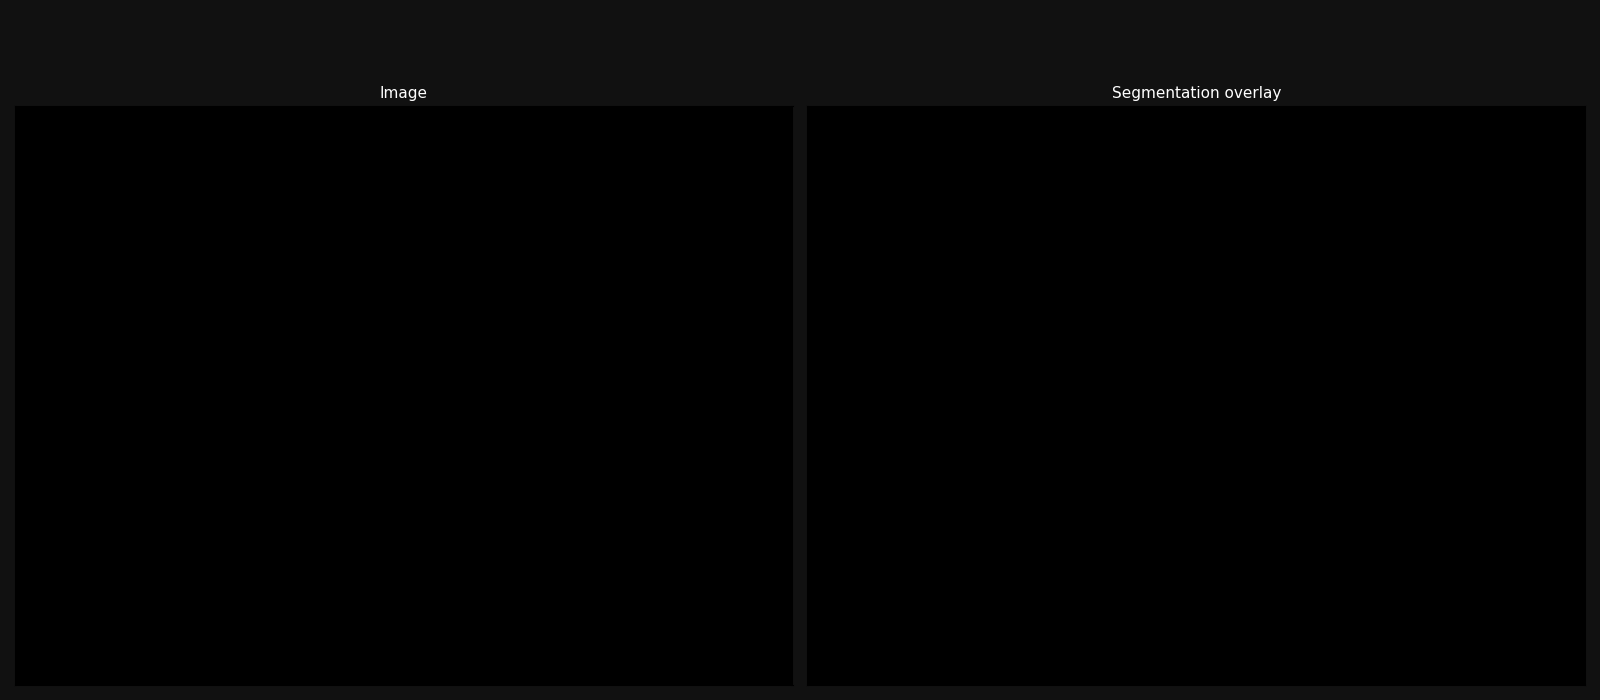

In [ ]:
import os
import glob
import re
import csv
import numpy as np
import nibabel as nib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import ipywidgets as w
from IPython.display import display
%matplotlib widget

BASE_DIR = "/users/project1/pt01190/sjs/Segmentacje"
SEQUENCE_MAP = {
    "T1_TSE": ("T1_TSE_Segmentation-label.nii.gz", r".*t1_tse_(?:tra|cor).*\.nii\.gz$"),
    "T2_DIXON_IN": ("T2_DIXON_in_Segmentation-label.nii.gz", r".*t2_tse_dixon.*_in.*\.nii\.gz$"),
    "T2_DIXON_F": ("T2_DIXON_F_Segmentation-label.nii.gz", r".*t2_tse_dixon.*_F.*\.nii\.gz$"),
    "T2_DIXON_W": ("T2_DIXON_W_Segmentation-label.nii.gz", r".*t2_tse_dixon.*_W.*\.nii\.gz$"),
    "ADC": ("ADC_Segmentation-label.nii.gz", r".*ep2d_diff.*\.nii\.gz$"),
    "T1_VIBE_IN": ("T1_VIBE_in_Segmentation-label.nii.gz", r".*t1_vibe_dixon.*_in.*\.nii\.gz$"),
    "T1_VIBE_F": ("T1_VIBE_F_Segmentation-label.nii.gz", r".*t1_vibe_dixon.*_F.*\.nii\.gz$"),
    "T1_VIBE_W": ("T1_VIBE_W_Segmentation-label.nii.gz", r".*t1_vibe_dixon.*_W.*\.nii\.gz$"),
    "T2_SPACE": ("T2_SPACE_Segmentation-label.nii.gz", r".*t[12]_space_tra.*iso_1\.0mm.*\.nii\.gz$"),
    "Sialo_MR": ("Sialo_MR_Segmentation-label.nii.gz", r".*Sialo-MR.*\.nii\.gz$"),
}


def get_patients():
    dirs = sorted(glob.glob(os.path.join(BASE_DIR, "*_Segmentacja*")))
    return [os.path.basename(d) for d in dirs if os.path.isdir(d)]


def find_file(folder, filename_or_pattern):
    exact_path = os.path.join(folder, filename_or_pattern)
    if os.path.isfile(exact_path):
        return exact_path
    try:
        pattern = re.compile(filename_or_pattern, re.IGNORECASE)
    except re.error:
        return None
    for name in sorted(os.listdir(folder)):
        if "-label.nii.gz" not in name and pattern.fullmatch(name):
            return os.path.join(folder, name)
    return None


def label_colors(labels):
    palette = [(0.90, 0.10, 0.10, 1.0), (0.05, 0.35, 0.95, 1.0),
               (0.05, 0.70, 0.20, 1.0), (1.00, 0.55, 0.00, 1.0)]
    return {label: palette[index % len(palette)] for index, label in enumerate(sorted(labels))}


class SegViewer:
    def __init__(self):
        self.patients = get_patients()
        if not self.patients:
            raise RuntimeError(f"No patient folders found under: {BASE_DIR}")
        self.img_data = self.seg_data = None
        self.img_nii = self.seg_nii = None
        self.seg_colors = {}
        self.mask_contours = []
        self.dd_patient = w.Dropdown(options=self.patients, description='Patient:', layout=w.Layout(width='260px'))
        self.dd_sequence = w.Dropdown(options=list(SEQUENCE_MAP), description='Sequence:', layout=w.Layout(width='260px'))
        self.sl_slice = w.IntSlider(value=0, min=0, max=1, step=1, description='Slice:', continuous_update=True, layout=w.Layout(width='480px'))
        self.lbl_warn = w.Label(value='', style={'description_width': '0px'})
        self.fig, self.axes = plt.subplots(1, 2, figsize=(16, 7))
        self.fig.patch.set_facecolor('#111')
        for axis in self.axes:
            axis.set_facecolor('black')
            axis.set_xticks([])
            axis.set_yticks([])
        blank = np.zeros((10, 10))
        transparent_blank = np.zeros((10, 10, 4), dtype=float)
        self.im_img = self.axes[0].imshow(blank, cmap='gray', aspect='auto')
        self.im_bg = self.axes[1].imshow(blank, cmap='gray', aspect='auto', alpha=0.70)
        self.im_seg = self.axes[1].imshow(transparent_blank, aspect='auto', alpha=1)
        self.axes[0].set_title('Image', color='white', fontsize=11)
        self.axes[1].set_title('Segmentation overlay', color='white', fontsize=11)
        self.legend = None
        self.fig_title = self.fig.suptitle('', color='white', fontsize=10, y=0.99)
        self.fig_meta = self.fig.text(0.5, 0.955, '', ha='center', va='top', color='#cfd8dc', fontsize=8)
        self.fig.tight_layout(rect=[0, 0, 1, 0.92])
        self.dd_patient.observe(self._on_source_change, names='value')
        self.dd_sequence.observe(self._on_source_change, names='value')
        self.sl_slice.observe(self._on_slice, names='value')
        display(w.VBox([w.HBox([self.dd_patient, self.dd_sequence]), self.sl_slice, self.lbl_warn]))
        plt.show()
        self._load_volume()

    def _format_nii_header_info(self, nii_obj, tag):
        if nii_obj is None:
            return f"{tag}: missing"
        hdr = nii_obj.header
        shape = tuple(int(v) for v in nii_obj.shape[:3])
        vox = tuple(float(v) for v in hdr.get_zooms()[:3])
        origin = nii_obj.affine[:3, 3]
        axcodes = ''.join(nib.aff2axcodes(nii_obj.affine))
        return (f"{tag}: shape={shape}, vox=({vox[0]:.3f},{vox[1]:.3f},{vox[2]:.3f}) mm, "
                f"dtype={hdr.get_data_dtype()}, ax={axcodes}, origin=({origin[0]:.1f},{origin[1]:.1f},{origin[2]:.1f})")

    def _load_volume(self):
        folder = os.path.join(BASE_DIR, self.dd_patient.value)
        seg_fname, img_pattern = SEQUENCE_MAP[self.dd_sequence.value]
        img_path = find_file(folder, img_pattern)
        seg_path = find_file(folder, seg_fname)
        warnings = []
        img_obj = nib.load(img_path) if img_path else None
        mask_obj = nib.load(seg_path) if seg_path else None
        if img_obj is not None:
            self.img_nii = nib.as_closest_canonical(img_obj)
            self.img_data = self.img_nii.get_fdata()
        else:
            self.img_nii = self.img_data = None
            warnings.append('image not found')
        if mask_obj is not None:
            self.seg_nii = nib.as_closest_canonical(mask_obj)
            self.seg_data = np.round(self.seg_nii.get_fdata()).astype(int)
        else:
            self.seg_nii = self.seg_data = None
            warnings.append('mask not found')
        self.seg_colors = label_colors(np.unique(self.seg_data[self.seg_data > 0]).astype(int).tolist()) if self.seg_data is not None else {}
        ref = self.seg_data if self.seg_data is not None else self.img_data
        if ref is not None:
            self.sl_slice.max = max(0, ref.shape[2] - 1)
            self.sl_slice.value = min(self.sl_slice.value, self.sl_slice.max)
        self.lbl_warn.value = '⚠ ' + ' | '.join(warnings) if warnings else ''
        self._update_display()

    def _on_source_change(self, change):
        self._load_volume()

    def _on_slice(self, change):
        self._update_display()

    def _update_display(self):
        sl = self.sl_slice.value
        image_slice = None
        if self.img_data is not None:
            image_slice = np.rot90(self.img_data[:, :, sl])
            self.im_img.set_data(image_slice)
            self.im_img.set_clim(image_slice.min(), image_slice.max())
            self.im_bg.set_data(image_slice)
            self.im_bg.set_clim(image_slice.min(), image_slice.max())
        for contour in self.mask_contours:
            contour.remove()
        self.mask_contours = []
        current_labels = []
        seg_slice = None
        if self.seg_data is not None:
            seg_slice = np.rot90(self.seg_data[:, :, sl])
            current_labels = np.unique(seg_slice[seg_slice > 0]).astype(int).tolist()
            rgba = np.zeros(seg_slice.shape + (4,), dtype=float)
            for label, color in self.seg_colors.items():
                rgba[seg_slice == label, :3] = color[:3]
            rgba[..., 3] = np.where(seg_slice > 0, 0.35, 0.0)
            self.im_seg.set_data(rgba)
            self.im_seg.set_alpha(1.0)
            for label in current_labels:
                contour = self.axes[1].contour(seg_slice == label, levels=[0.5], colors=[self.seg_colors[label]], linewidths=1.4, alpha=0.8)
                self.mask_contours.append(contour)
            if self.legend is not None:
                self.legend.remove()
            handles = [Patch(facecolor=self.seg_colors[label], edgecolor='white', label=f'Label {label}') for label in sorted(self.seg_colors)]
            self.legend = self.axes[1].legend(handles=handles, loc='upper right', fontsize=8, framealpha=0.8) if handles else None
        else:
            self.im_seg.set_alpha(0)
            if self.legend is not None:
                self.legend.remove()
                self.legend = None
        display_shape = image_slice.shape if image_slice is not None else seg_slice.shape if seg_slice is not None else (10, 10)
        height, width = display_shape
        extent = (0, width, height, 0)
        self.im_img.set_extent(extent)
        self.im_bg.set_extent(extent)
        if seg_slice is not None:
            self.im_seg.set_extent(extent)
        for axis in self.axes:
            axis.set_xlim(0, width)
            axis.set_ylim(height, 0)
        all_labels = sorted(self.seg_colors)
        self.fig_title.set_text(f"{self.dd_patient.value} · {self.dd_sequence.value} · slice {sl}/{self.sl_slice.max}")
        img_info = self._format_nii_header_info(self.img_nii, 'IMG')
        seg_info = self._format_nii_header_info(self.seg_nii, 'SEG')
        self.fig_meta.set_text(f"{img_info}\n{seg_info}\nlabels all={all_labels}; slice={current_labels}")
        self.fig.canvas.draw_idle()


SegViewer()